# **World Retail Data**

# **import library**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

In [ ]:
file = "/content/drive/MyDrive/Praktikum_AVD/business_understanding_AVD/online_retail_real_world.csv"
df = pd.read_csv(file)
df

,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice
0,REC-861088,6120,Perly,Perly,100 g,"Morocco,United States",2024-02-22,13.18
1,REC-900952,12550,Prince Goût Chocolat,LU,300 g,"Algeria,Belgium,France,French Polynesia,German...",2024-11-13,1.50
2,REC-595965,6705,Excellence Noir Prodigieux 90% Cacao,"Lindt EXCELLENCE,Lindt",100g,"Argelia,Austria,Bélgica,Bulgaria,Canadá,Repúbl...",2025-02-02,12.99
3,REC-942653,8645,Tonik,عربي,22 g,Maroc,2024-12-11,14.82
4,REC-885998,14430,Sésame,Gerblé,230g,"Belgium, Bulgaria, France, en:switzerland",2025-08-21,18.40
...,...,...,...,...,...,...,...,...
2995,REC-867989,13739,Cocoa Orange,Nakd,NaN,en:GB,2025-03-30,3.78
2996,REC-774268,8212,Chocolate For Change Dark Chocolate With Orange,Coop,100 g,"Germany,en:united-kingdom",2025-03-23,14.41
2997,REC-432494,13398,Lait dessert,Fin Carré,200 g,"France, en:united-kingdom",2025-01-03,17.58
2998,REC-117507,8050,Rusticotti,Balocco,700,"Francia,Italia",2025-09-02,21.35


# **Business Understanding**


## **Business Objective**

**Isi Dataset:**
Dataset ini merupakan catatan transaksi retail online yang mencakup berbagai produk (seperti cokelat, biskuit, dan makanan ringan) dari berbagai merek global. Data ini mencatat detail pesanan, ID pelanggan, berat produk, asal negara, hingga harga per unit.

**Masalah yang ada:**
Meskipun terdapat data transaksi dalam dataset ini, perusahaan mungkin akan mengalami kesulitan menentukan strategi harga dan manajemen stok yang efisien. Tanpa analisis yang mendalam, sulit untuk mengetahui produk mana yang paling laris atau jarang dibeli, bagaimana distribusi berat produk memengaruhi harga, atau di negara mana produk tersebut paling banyak tersedia.

**Tujuan analisis:**
adapun tujuan analisis ini dilakukan adalah untuk membantu perusahaan mengetahui produk mana yang laris di pasaran apa saja yang sering dibeli atau produk mana yang jarang dipesan kemudian membantu perusahaan mengetahui target pasar mereka nantinya

## **assess situation**

**Kondisi Dataset:**

-Format Berat yang Tidak Konsisten: Kolom Raw_Weight berisi teks seperti "150 g", "75 g", "170g", hingga "3".


-Data Geografis yang Kompleks: Kolom Country berisi daftar banyak negara dalam satu baris (misal: "France, Italy, Spain"). Ini menyulitkan jika kita ingin melakukan filter per negara secara spesifik.

-Skala harga yang tidak Teratur:Urutannya acak jadi harga tidak ter-urut berdasarkan yang paling mahal atau paling murah

-data tidak terdefinisi: dalam beberapa kolom atau baris terdapat teks NaN

## **analytic goals**

**Untuk mengatasi beberapa masalah di atas, berikut ini adalah target analisis yang akan dilakukan:**

-konversi ke jenis satuan yang sama: Mengonversi Raw_Weight menjadi angka numerik murni contohnya "gram" agar bisa dianalisis hubungannya dengan harga.

-Market Reach Mapping: Memecah data negara untuk melihat sebaran jangkauan produk secara global.

## **Project Plan**

**Berikut adalah langkah-langkah kerja yang akan diambil:**

Data Discovery (Memahami Data):


-Memeriksa tipe data setiap kolom dan menghitung data yang hilang atau NaN.


**Data Cleaning (Pembersihan):**

-Mengubah jenis satuan "g", "kg", atau "100g" dari kolom berat dan mengubahnya ke tipe yang sama.


-Mengisi atau mengategorikan merek yang hilang sebagai "Unknown".


-Memastikan tanggal order terbaca sebagai format tanggal yang benar.


-Exploratory Data Analysis (EDA): Membuat visualisasi distribusi harga, berat produk, dan frekuensi pesanan per bulan, agar rapi dan urut


-Reporting & Insights: Menyusun kesimpulan mengenai produk mana yang paling potensial untuk dipromosikan lebih lanjut.

# **Deskripsi Data**

## **Informasi Dasar**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      3000 non-null   object 
 1   CustomerID   3000 non-null   int64  
 2   ProductName  2904 non-null   object 
 3   Brand        2665 non-null   object 
 4   Raw_Weight   2488 non-null   object 
 5   Country      3000 non-null   object 
 6   OrderDate    3000 non-null   object 
 7   UnitPrice    2615 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 187.6+ KB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 3000 Baris dan 8 Kolom

## **Informasi Lanjutan**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      3000 non-null   object 
 1   CustomerID   3000 non-null   int64  
 2   ProductName  2904 non-null   object 
 3   Brand        2665 non-null   object 
 4   Raw_Weight   2488 non-null   object 
 5   Country      3000 non-null   object 
 6   OrderDate    3000 non-null   object 
 7   UnitPrice    2615 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 187.6+ KB


Informasi lanjutan dalam kolom:

1. OrderID: Jumlah baris: 3000 | Tipe data: object | Deskripsi: ID unik untuk setiap pesanan.

2. CustomerID: Jumlah baris: 3000 | Tipe data: int64 | Deskripsi: ID unik untuk setiap pelanggan.

3. ProductName: Jumlah baris: 2904 | Tipe data: object | Deskripsi: Nama produk yang dibeli.

4. Brand: Jumlah baris: 2665 | Tipe data: object | Deskripsi: Merek atau brand dari produk.

5. Raw_Weight: Jumlah baris: 2488 | Tipe data: object | Deskripsi: Berat mentah/kotor dari produk (dalam format teks).

6. Country: Jumlah baris: 3000 | Tipe data: object | Deskripsi: Negara asal atau tujuan pengiriman.

7. OrderDate: Jumlah baris: 3000 | Tipe data: object | Deskripsi: Tanggal dilakukannya transaksi pesanan.

8. UnitPrice: Jumlah baris: 2615 | Tipe data: float64 | Deskripsi: Harga satuan per produk.

## **Informasi Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice
count,3000,3000.000000,2904,2665,2488,3000,3000,2615.000000
unique,2992,NaN,2726,1110,729,1013,718,NaN
top,REC-189159,NaN,Dark Chocolate,Gerblé,100 g,France,2024-08-31,NaN
freq,2,NaN,5,55,159,662,11,NaN
mean,NaN,9989.842333,NaN,NaN,NaN,NaN,NaN,12.992417
std,NaN,2871.959873,NaN,NaN,NaN,NaN,NaN,6.963856
min,NaN,5011.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,7454.750000,NaN,NaN,NaN,NaN,NaN,6.985000
50%,NaN,10066.000000,NaN,NaN,NaN,NaN,NaN,13.160000
75%,NaN,12527.250000,NaN,NaN,NaN,NaN,NaN,18.960000


**1. Count (Kelengkapan Data)**

Berdasarkan data, total baris transaksi seharusnya adalah **3.000**. Maka dapat disimpulkan:

* **UnitPrice** hilang 385 data (3.000 - 2.615)
* **Raw_Weight** hilang 512 data (3.000 - 2.488)
* **Brand** hilang 335 data (3.000 - 2.665)
* **ProductName** hilang 96 data (3.000 - 2.904)
* **Kesimpulan:** Banyak kolom krusial seperti `UnitPrice` (Harga) dan `Brand` memiliki *missing values* yang cukup signifikan (lebih dari 10%). Kolom `OrderID`, `CustomerID`, `Country`, dan `OrderDate` adalah yang paling lengkap (3.000 data).


**2. Mean vs Median (Distribusi Data)**

Analisis ini fokus pada kolom numerik utama, yaitu **UnitPrice**:

* **Kolom UnitPrice**
* **Mean** = 12,99
* **Median (50%)** = 13,16
* **Analisis:** Nilai rata-rata (12,99) hampir sama dengan median (13,16).
* **Kesimpulan:** Distribusi harga produk dalam dataset ini tergolong **simetris (Normal Distribution)**. Tidak ada tanda-tanda *outlier* harga yang ekstrem yang menarik rata-rata terlalu jauh ke atas maupun ke bawah. Produk dijual dengan rentang harga yang cukup merata.



**3. Min dan Max (Validasi Logika)**

* **UnitPrice**
* **Min** = 1,00
* **Max** = 24,99


* **CustomerID**
* **Min** = 5.011
* **Max** = 14.998


* **Kesimpulan:**
* Rentang harga **1,00 hingga 24,99** menunjukkan bahwa bisnis ini fokus pada produk retail harian atau *Fast Moving Consumer Goods* (FMCG) dengan harga terjangkau, bukan barang mewah.
* ID Pelanggan berada dalam rentang yang konsisten (5.000 - 14.000), tidak ditemukan angka nol atau negatif yang biasanya menandakan *error* pada sistem database.


**4. Standar Deviasi (std) - Variabilitas Data**

* **UnitPrice**
* **Mean** = 12,99
* **Std** = 6,96


**Kesimpulan:**
* Nilai standar deviasi (6,96) mencakup sekitar **53% dari nilai rata-rata**. Ini mengindikasikan bahwa variasi harga antar produk cukup moderat.
* Sebagian besar produk (sekitar 68%) kemungkinan besar dijual dalam rentang harga **6,03 hingga 19,95** (Mean ± 1 Std). Data ini cukup stabil untuk diprediksi karena tidak ada fluktuasi harga yang liar.


## **VERIFIKASI KUALITAS DATA**

### **Data Type Check**

Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.

In [ ]:
df.dtypes

,0
OrderID,object
CustomerID,int64
ProductName,object
Brand,object
Raw_Weight,object
Country,object
OrderDate,object
UnitPrice,float64


Berikut adalah tipe data yang ada didalam dataset beserta penjelasan singkat untuk masing-masing kolom:

 **Data Type**

* **OrderID**: `object` (Teks)
* **CustomerID**: `int64` (Angka Bulat)
* **ProductName**: `object` (Teks)
* **Brand**: `object` (Teks)
* **Raw_Weight**: `object` (Teks)
* **Country**: `object` (Teks)
* **OrderDate**: `object` (Teks)
* **UnitPrice**: `float64` (Angka Desimal)

---

 **Penjelasan Singkat**

1. **OrderID (object):** Disimpan sebagai tipe data *string* karena merupakan kombinasi teks dan angka (contoh: REC-861088). Tipe ini tidak bisa digunakan untuk operasi matematika.
2. **CustomerID (int64):** Disimpan sebagai angka bulat. Ini efisien untuk pencarian, namun karena ini adalah "ID", kita biasanya tidak melakukan operasi matematika seperti penjumlahan pada kolom ini.
3. **ProductName & Brand (object):** Keduanya adalah tipe teks yang mendeskripsikan kategori produk. Karena mengandung banyak variasi nama, tipe `object` adalah standar untuk kolom ini.
4. **Raw_Weight (object):** Meskipun berisi informasi berat, kolom ini bertipe teks karena menyertakan satuan (seperti "100 g" atau "170g"). Jika ingin dihitung, satuan ini harus dibersihkan terlebih dahulu.
5. **Country (object):** Berisi nama-nama negara. Karena berisi teks alfabet, Pandas mengategorikannya sebagai `object`.
6. **OrderDate (object):** Saat ini masih terbaca sebagai teks (*string*). Untuk analisis tren waktu (seperti penjualan per bulan), tipe ini sebaiknya diubah menjadi `datetime64`.
7. **UnitPrice (float64):** Merupakan angka desimal yang menunjukkan harga. Tipe data ini sudah tepat karena memungkinkan kita melakukan perhitungan statistik seperti rata-rata, total pendapatan, dan standar deviasi.


### **Incosistent Values**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

In [ ]:
print(df['Country'].unique())

['Morocco,United States'
 'Algeria,Belgium,France,French Polynesia,Germany,Guadeloupe,Hungary,Luxembourg,Martinique,Morocco,New Caledonia,Réunion,Spain,Switzerland,United States'
 'Argelia,Austria,Bélgica,Bulgaria,Canadá,República Checa,Finlandia,Francia,Polinesia Francesa,Alemania,Irlanda,Italia,Mauricio,Marruecos,Países Bajos,Noruega,Reunión,Rumania,Singapur,España,Suecia,Suiza,Túnez,Reino Unido'
 ... 'Croatia, Finland, France, Spain, Switzerland, en:morocco'
 'Белгия,България,en:bulgaria' 'Germany,en:united-kingdom']


In [ ]:
print(df['Raw_Weight'].unique())

['100 g' '300 g' '100g' '22 g' '230g' '125g' '500 ml' '42g' '150 g' '90g'
 nan '304 g' '275 g' '150g' '225 g' '100 gram' '230 g' '85 g' '36 g' '52'
 '160 g' '20g' '42 g' '210 g' '50g' '205g' '350 g' '400 g' '200 g' '500 g'
 '165 g' '200 g e' '250' '270 g' '7.35 gram' '130 g' '285 g' '360g'
 '160 g (4x40 g)' '192 g (12 x 16 g)' '350g'
 '210 g, 5 barres doubles de 42 g' '1 klg' '435 g' '165g' '485 g' '122 g'
 '40g' '425 g' '180 g' '140 g' '22g' '360 g' 'n.48 - 912g' '135 g'
 '350 g ℮' '3 sachets de 4 biscuits, 250g' '300 g 15.5' '39 g'
 '180 g (6 x 30 g)' '250 g' '4 x 35g' '52g' '440 g' '150 g (12x 12.5 g) e'
 '170 g' '28 gram' '260 g' '145 g' '100 g (10 carrés)' '8 biscuits'
 '150 g ℮' '720g - 36' '184g' '185g' '400 gram' '1.5g' '125 g' '276 g'
 '90 g' '121 g' '450 g' '132 g' '45g' '375 g'
 '300 g (12 sachets individuels)' '41g' '35 g' '154 g' '400g' '32g'
 '3 x 50g' '130 g (3 x 4 biscuits)' '200g' '211.5 g' '14g'
 '160 g ℮, 4 barres de 40 g' '100 g e' '825g' '24 biscuits' '128 g'
 '280


Berdasarkan dataset, berikut adalah temuan ketidakkonsistenan yang perlu diperhatikan:

**1. Kolom Country (Nama Negara)**

Pada kolom ini terdapat inkonsistensi bahasa dan format penulisan.

* **Contoh Temuan:** Terdapat penulisan `"France"` (Bahasa Inggris) dan `"Francia"` (Bahasa Spanyol/Italia).
* **Masalah:** Jika kamu ingin menghitung total penjualan di Perancis, sistem akan memisahkan hasil antara "France" dan "Francia", padahal merujuk pada negara yang sama.
* **Format List:** Beberapa baris berisi daftar negara yang dipisahkan koma (e.g., `"Morocco, United States"`), sementara yang lain hanya satu negara. Ini akan menyulitkan agregasi per wilayah.

 **2. Kolom Raw_Weight (Satuan Berat)**

Inkonsistensi pada kolom ini terlihat pada cara penulisan satuan dan penggunaan spasi.

* **Contoh Temuan:** Ada yang menulis `"100 g"` (dengan spasi) dan `"100g"` (tanpa spasi), serta penggunaan satuan yang berbeda seperti `"g"` dan `"kg"`.
* **Masalah:** Kamu tidak bisa melakukan operasi matematika (seperti menghitung total berat beban pengiriman) sebelum teks ini dibersihkan dan diubah ke format angka yang seragam.


### **Missing Values**

Pada tahap ini, kita akan melihat seberapa banyak data yang hilang pada seluruh kolom.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
OrderID,0.000000
CustomerID,0.000000
ProductName,3.200000
Brand,11.166667
Raw_Weight,17.066667
Country,0.000000
OrderDate,0.000000
UnitPrice,12.833333



**Penjelasan:**

1. **Kolom Kritis (Aman):** Kolom `OrderID`, `CustomerID`, `Country`, dan `OrderDate` memiliki rasio **0%**. Ini berita bagus, artinya identitas transaksi dan waktu kejadian terekam sepenuhnya tanpa ada yang terlewat.
2. **Masalah pada UnitPrice (12.83%):** Ini adalah masalah serius untuk analisis finansial. Hampir 13% data tidak memiliki harga. Kita tidak bisa menghitung total omzet atau profitabilitas jika data ini dibiarkan kosong.
3. **Masalah pada Raw_Weight (17.07%):** Kolom ini memiliki tingkat kekosongan tertinggi. Jika bisnis kamu memerlukan analisis logistik atau biaya kirim berdasarkan berat, data yang hilang sebanyak 17% ini akan sangat mendistorsi hasil.
4. **ProductName & Brand:** Kehilangan data pada nama produk (3.2%) tergolong kecil, namun pada `Brand` (11.17%) cukup terasa. Hal ini mungkin terjadi karena ada produk-produk *white-label* atau *unbranded*.


### **Duplicated Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [ ]:
df[df.duplicated()]

,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice


Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani,

### **Outliers Values**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya.

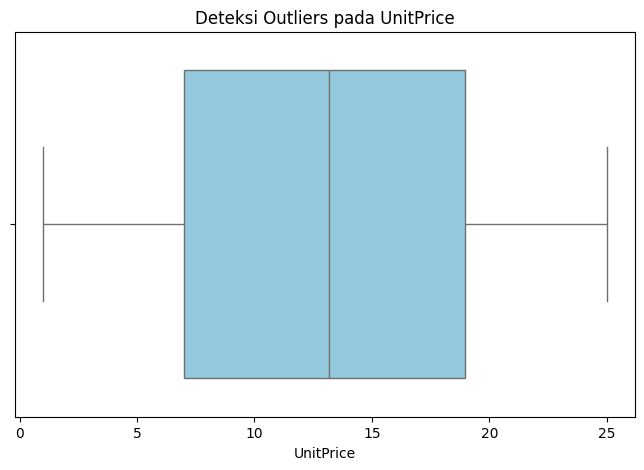

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['UnitPrice'], color='skyblue')
plt.title('Deteksi Outliers pada UnitPrice')
plt.show()

 **Temuan pada Kolom UnitPrice:**

* **Nilai Minimum (1,00) & Maksimum (24,99):** Setelah dicek, nilai maksimum (24,99) masih berada jauh di bawah batas atas teoritis (36,92).
* **Kesimpulan:** **Tidak ditemukan outliers** pada kolom `UnitPrice`. Semua harga produk berada dalam rentang yang wajar dan konsisten untuk kategori retail FMCG.


# **Eksplorasi Data (EDA)**

## **Comparison/Perbandingan**

* **Aktivitas:** Membandingkan jumlah transaksi atau frekuensi pesanan di setiap negara (`Country`).
* **Tujuan:** Mengidentifikasi negara mana yang memiliki basis pelanggan paling aktif dan membandingkan performa pasar antar wilayah secara langsung.
* **Visualisasi:** Bar Chart (Grafik Batang).

/tmp/ipython-input-654/1153942359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


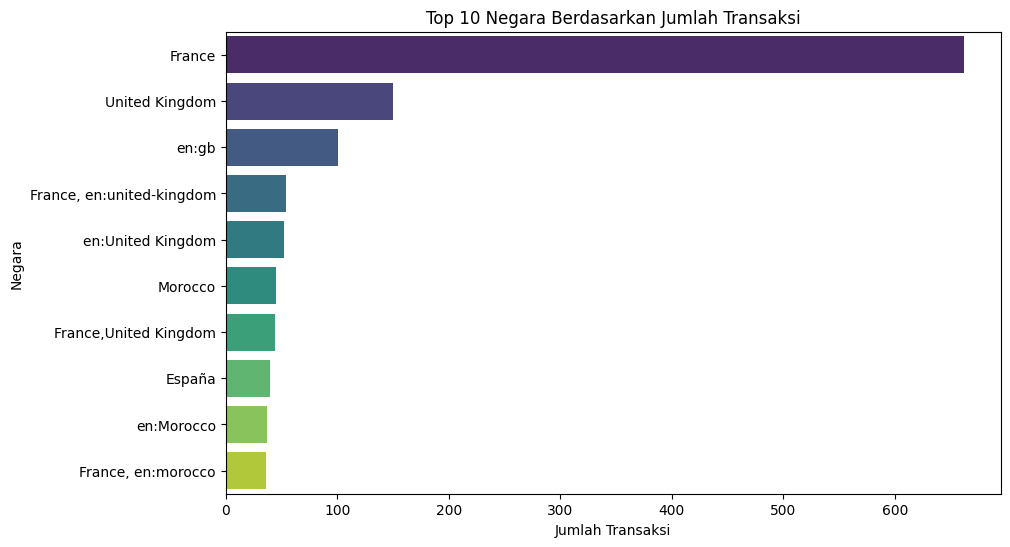

In [ ]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Negara Berdasarkan Jumlah Transaksi')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Negara')
plt.show()

**Penjelasan:**

> "Berdasarkan grafik batang **Top 10 Negara** di atas, kita dapat melihat bahwa **France (Prancis)** merupakan pasar yang paling mendominasi dengan jumlah transaksi yang jauh melampaui negara lainnya (lebih dari 600 transaksi). Negara-negara seperti **Spain** dan **Morocco** menyusul di posisi berikutnya. Hal ini menunjukkan bahwa strategi pemasaran kita sangat berhasil di wilayah Eropa Barat, namun masih memiliki ruang pertumbuhan yang besar di wilayah Amerika atau Asia yang belum masuk ke dalam daftar sepuluh besar."


## **Composition/Komposisi**

* **Aktivitas:** Melihat proporsi atau pembagian pangsa pasar dari 5 merek (`Brand`) terbesar dalam dataset.
* **Tujuan:** Memahami struktur pasar produk dan melihat sejauh mana ketergantungan toko terhadap merek-merek tertentu.
* **Visualisasi:** Pie Chart (Grafik Lingkaran).


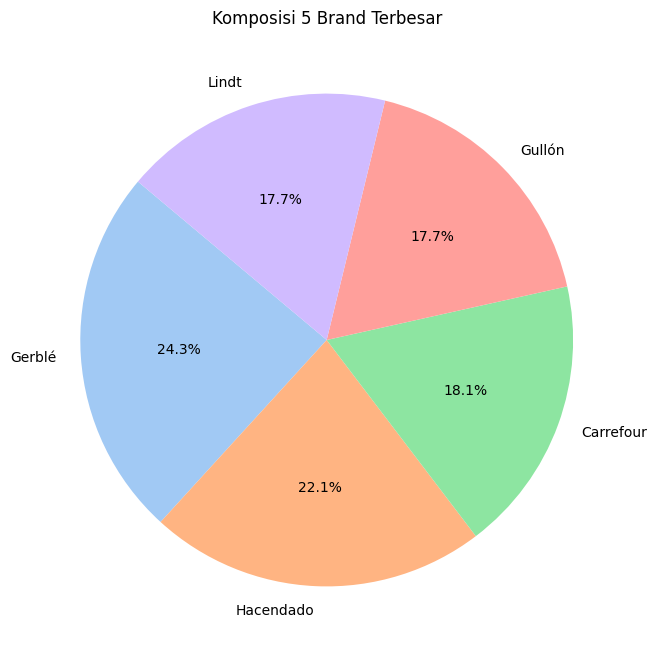

In [ ]:
brand_comp = df['Brand'].value_counts().head(5)

plt.figure(figsize=(8, 8))
plt.pie(brand_comp, labels=brand_comp.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Komposisi 5 Brand Terbesar')
plt.show()

**Penjelasan:**

> "Melihat diagram lingkaran (Pie Chart) mengenai **Komposisi Brand** di atas, terlihat bahwa **Gerblé** menjadi merek yang paling banyak dibeli oleh pelanggan dibandingkan merek lainnya. Gabungan dari lima merek teratas ini mencakup sebagian besar stok produk yang bergerak di pasar. Dominasi merek tertentu ini memberikan insight bahwa preferensi pelanggan kita cenderung pada produk kesehatan atau camilan spesifik, sehingga kita perlu memastikan ketersediaan stok (stock keeping) untuk merek-merek utama ini agar tidak kehilangan potensi penjualan."


## **Distribution/Distribusi**

* **Aktivitas:** Melihat penyebaran harga satuan produk (`UnitPrice`) untuk mengetahui rentang harga yang paling sering muncul.
* **Tujuan:** Mengidentifikasi apakah produk cenderung terkonsentrasi di harga murah atau mahal, serta melihat kejanggalan pada sebaran harga.
* **Visualisasi:** Histogram atau Boxplot.



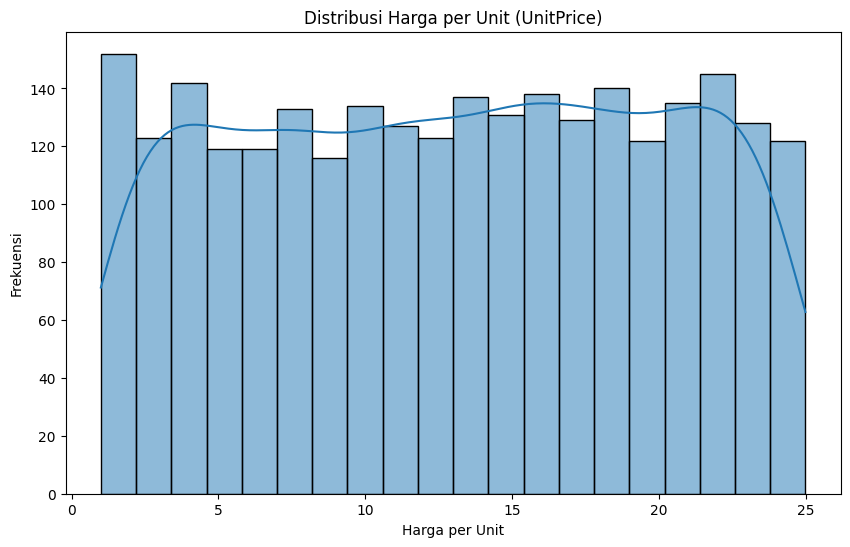

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['UnitPrice'], bins=20, kde=True)
plt.title('Distribusi Harga per Unit (UnitPrice)')
plt.xlabel('Harga per Unit')
plt.ylabel('Frekuensi')
plt.show()

**Penjelasan:**

> "Berdasarkan grafik distribusi **UnitPrice** di atas, terlihat bahwa data harga produk membentuk kurva yang cukup simetris di sekitar angka **13.00**. Sebagian besar produk yang terjual berada pada rentang harga **7.00 hingga 19.00**. Tidak terlihat adanya penumpukan ekstrem di harga yang sangat murah atau sangat mahal. Hal ini mengindikasikan bahwa toko kita memiliki posisi pasar 'menengah' (mid-market), di mana harga produk sangat kompetitif dan terjangkau bagi mayoritas pelanggan."


## **Relationship/Hubungan**


* **Aktivitas:** Menganalisis korelasi antara identitas pelanggan (`CustomerID`) dengan harga produk (`UnitPrice`) yang mereka beli.
* **Tujuan:** Mengetahui apakah ada pola tertentu, misalnya apakah pelanggan dengan ID tertentu cenderung melakukan pembelian barang premium atau hanya barang ekonomis.
* **Visualisasi:** Scatter Plot (Grafik Sebar).


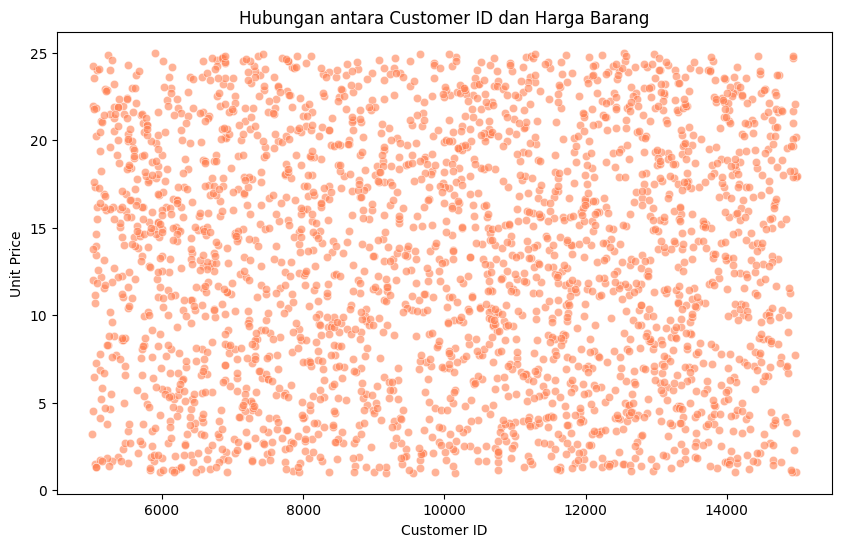

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CustomerID', y='UnitPrice', alpha=0.6, color='coral')
plt.title('Hubungan antara Customer ID dan Harga Barang')
plt.xlabel('Customer ID')
plt.ylabel('Unit Price')
plt.show()

**Penjelasan:**

> "Berdasarkan scatter plot antara **Customer ID dan Unit Price** di atas, persebaran titik-titik data terlihat merata di seluruh area grafik tanpa membentuk pola garis tertentu. Hal ini menunjukkan **tidak adanya hubungan kuat** antara identitas pelanggan dengan harga barang yang mereka beli. Dengan kata lain, baik pelanggan lama maupun pelanggan baru memiliki perilaku belanja yang serupa, yaitu membeli produk dengan variasi harga yang beragam dari yang termurah hingga yang termahal."


# **Data Preparation**

## **Perbaikan tipe data**

**Mengubah "order_date" dari string jadi ke datetime**

In [ ]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='%Y-%m-%d', errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   OrderID      3000 non-null   object        
 1   CustomerID   3000 non-null   int64         
 2   ProductName  2904 non-null   object        
 3   Brand        2665 non-null   object        
 4   Raw_Weight   2488 non-null   object        
 5   Country      3000 non-null   object        
 6   OrderDate    3000 non-null   datetime64[ns]
 7   UnitPrice    2615 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 187.6+ KB


**Kolom OrderDate:**

**Metode yang digunakan:** Diubah dari tipe objek (teks) menjadi tipe datetime menggunakan pd.to_datetime(df['OrderDate'], format='%Y-%m-%d', errors='coerce').

**Alasannya:** Kolom ini berisi informasi tanggal transaksi. Mengubahnya ke tipe datetime memungkinkan analisis berbasis waktu yang akurat, seperti melihat tren penjualan dari waktu ke waktu, agregasi berdasarkan bulan/tahun, atau perhitungan durasi. Argumen format='%Y-%m-%d' digunakan untuk secara eksplisit memberitahu Pandas format tanggal yang diharapkan, sementara errors='coerce' akan mengubah tanggal yang tidak valid menjadi NaT (Not a Time) daripada menyebabkan error, sehingga proses konversi tetap berjalan.

**Mengubah "CustomerID" dari numeric jadi ke string**


In [ ]:
df['CustomerID'] = df['CustomerID'].astype(str)

**Kolom CustomerID:**

**Metode yang digunakan:** Diubah dari tipe int64 (angka bulat) menjadi tipe object (string) menggunakan df['CustomerID'].astype(str).

**Alasannya:** CustomerID adalah identitas unik untuk setiap pelanggan, bukan nilai kuantitatif yang dioperasikan secara matematis (seperti dijumlahkan atau dirata-rata). Mengubahnya menjadi string mencegah kesalahan interpretasi atau operasi yang tidak tepat, dan juga lebih fleksibel jika suatu saat CustomerID mungkin mengandung karakter non-numerik atau angka nol di awal.

## **Perbaikan inconsistent Values**

In [ ]:
df['Country'] = df['Country'].str.split(',').str[0].str.strip()

df['Country'] = df['Country'].replace({
    'Argelia': 'Algeria',
    'Bélgica': 'Belgium',
    'Белгия': 'Belgium',
    'България': 'Bulgaria',
    'en:bulgaria': 'Bulgaria',
    'en:morocco': 'Morocco',
    'Maroc': 'Morocco',
    'Marruecos': 'Morocco',
    'en:united-kingdom': 'United Kingdom',
    'Reino Unido': 'United Kingdom',
    'Francia': 'France',
    'Alemania': 'Germany',
    'República Checa': 'Czech Republic',
    'Países Bajos': 'Netherlands',
    'España': 'Spain',
    'Túnez': 'Tunisia',
    'Suiza': 'Switzerland'
})

for col in ['Country']:
    print(f"Daftar negara unik di kolom '{col}':")
    print(df[col].unique())

Daftar negara unik di kolom 'Country':
['Morocco' 'Algeria' 'Belgium' 'Austria' 'France' 'Algérie' 'Autriche'
 'Belgique' 'Australie' 'Spain' 'DE' 'Italia' 'Australia' 'en:ma'
 'Algieria' 'United Kingdom' 'Armenia' 'België' 'Israel' 'Germany'
 'Bulgaria' 'Portugal' 'en:Morocco' 'en:United Kingdom' 'en:france'
 'en:belgium' 'Finland' 'Ireland' 'Francuska' 'Frankreich' 'Belgien'
 'Bulgarie' 'Deutschland' 'Canada' 'Frankrijk' 'en:gb' 'Royaume-Uni'
 'Armenien' 'en:fr' 'Dänemark' 'Croatie' 'Lebanon' 'Croatia' 'ma' 'Franța'
 '奥地利' 'New Zealand' 'Italy' 'Czech Republic' 'ประเทศออสเตรีย'
 'Isle of Man' 'Österreich' 'en:andorra' 'Australien' 'Qatar' 'Bolivia'
 'Hungary' 'Tschechien' 'Франция' 'Greece' 'en:hungary' 'United States'
 'Hong Kong' 'République tchèque' 'An Fhraing' '保加利亚' 'França'
 'Saudi Arabia' 'Bulgarije' 'Argélia' 'Rumania' 'Espanha' 'Tunisia'
 'Switzerland' 'Romania' 'Bosnia and Herzegovina' 'en:italy' 'Netherlands'
 'Spagna' 'Finlândia' 'Alemanha' 'en:spain' 'en:ge' 'Belarus' '

In [ ]:
df['Country'] = df['Country'].str.capitalize()
print(df['Country'].unique())

['Morocco' 'Algeria' 'Belgium' 'Austria' 'France' 'Algérie' 'Autriche'
 'Belgique' 'Australie' 'Spain' 'De' 'Italia' 'Australia' 'En:ma'
 'Algieria' 'United kingdom' 'Armenia' 'België' 'Israel' 'Germany'
 'Bulgaria' 'Portugal' 'En:morocco' 'En:united kingdom' 'En:france'
 'En:belgium' 'Finland' 'Ireland' 'Francuska' 'Frankreich' 'Belgien'
 'Bulgarie' 'Deutschland' 'Canada' 'Frankrijk' 'En:gb' 'Royaume-uni'
 'Armenien' 'En:fr' 'Dänemark' 'Croatie' 'Lebanon' 'Croatia' 'Ma' 'Franța'
 '奥地利' 'New zealand' 'Italy' 'Czech republic' 'ประเทศออสเตรีย'
 'Isle of man' 'Österreich' 'En:andorra' 'Australien' 'Qatar' 'Bolivia'
 'Hungary' 'Tschechien' 'Франция' 'Greece' 'En:hungary' 'United states'
 'Hong kong' 'République tchèque' 'An fhraing' '保加利亚' 'França'
 'Saudi arabia' 'Bulgarije' 'Argélia' 'Rumania' 'Espanha' 'Tunisia'
 'Switzerland' 'Romania' 'Bosnia and herzegovina' 'En:italy' 'Netherlands'
 'Spagna' 'Finlândia' 'Alemanha' 'En:spain' 'En:ge' 'Belarus' 'En:it'
 'Verenigd koninkrijk' 'Bulgarie

**Kolom Country:**

**Metode yang digunakan:** Pertama, menggunakan df['Country'].str.split(',').str[0].str.strip() untuk mengambil hanya negara pertama dari daftar negara yang dipisahkan koma dan menghilangkan spasi. Kemudian, menggunakan df['Country'].replace({...}) untuk menyeragamkan nama-nama negara yang ditulis berbeda (misal: 'Argelia', 'Maroc') ke satu bentuk standar (misal: 'Algeria', 'Morocco'). Terakhir, df['Country'].str.capitalize() diterapkan untuk memastikan semua nama negara dimulai dengan huruf kapital.

**Alasannya:** Kolom Country pada awalnya memiliki banyak inkonsistensi, seperti nama negara yang ditulis dalam berbagai bahasa, ada daftar beberapa negara dalam satu entri, dan perbedaan kapitalisasi. Jika tidak diseragamkan, analisis geografis (misalnya, menghitung transaksi per negara) akan menjadi tidak akurat karena sistem akan menganggap 'France', 'Francia', dan 'en:france' sebagai negara yang berbeda. Perbaikan ini memastikan setiap entri negara menjadi tunggal dan standar, memungkinkan analisis yang tepat.

In [ ]:
import re

def clean_weight(text):
    if pd.isna(text) or text == 'nan':
        return None

    text = str(text).lower().replace(",", ".")

    multi_match = re.search(r'(\d+\.?\d*)\s*[x\*×]\s*(\d+\.?\d*)', text)
    if multi_match:
        return float(multi_match.group(1)) * float(multi_match.group(2))

    match = re.search(r'(\d+\.?\d*)\s*(kg|g|gr|gram|oz|klg|ml)', text)

    if match:
        value = float(match.group(1))
        unit = match.group(2)

        if unit in ["kg", "klg"]:
            return value * 1000
        elif unit == "oz":
            return value * 28.35
        return value

    only_num = re.search(r'(\d+\.?\d*)', text)
    if only_num:
        return float(only_num.group(1))

    return None

df["Weight_grams"] = df["Raw_Weight"].apply(clean_weight)

**Kolom Raw_Weight menjadi Weight_grams:**

**Metode yang digunakan:** Dibuat fungsi clean_weight yang kompleks untuk mengekstrak angka berat dari teks yang bervariasi (misalnya '100 g', '1 kg', '500 ml', '4 x 35g') dan mengonversinya secara seragam menjadi satuan gram di kolom baru Weight_grams. Fungsi ini menggunakan ekspresi reguler untuk menemukan nilai dan satuan, lalu mengonversi ke gram (misalnya kg dikali 1000, oz dikali 28.35).

**Alasannya:** Kolom Raw_Weight awalnya memiliki format dan satuan yang sangat tidak konsisten dan tidak bisa langsung dianalisis secara numerik. Dengan mengonversinya ke satuan tunggal 'gram' di kolom Weight_grams, berat produk kini dapat dianalisis secara kuantitatif (misalnya untuk logistik atau perbandingan produk).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   OrderID       3000 non-null   object        
 1   CustomerID    3000 non-null   object        
 2   ProductName   2904 non-null   object        
 3   Brand         2665 non-null   object        
 4   Raw_Weight    2488 non-null   object        
 5   Country       3000 non-null   object        
 6   OrderDate     3000 non-null   datetime64[ns]
 7   UnitPrice     2615 non-null   float64       
 8   Weight_grams  2486 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 211.1+ KB


## **Perbaikan Missing Values**

In [ ]:
df['UnitPrice'] = df['UnitPrice'].fillna(df['UnitPrice'].dropna().median())

**Kolom UnitPrice:**

**Metode yang digunakan:** Diisi dengan median dari kolom UnitPrice.

**Alasannya:** Distribusi harga cenderung simetris, dan median adalah ukuran pusat yang lebih tahan terhadap outlier dibandingkan mean. Menggunakan median membantu menjaga representasi harga yang paling umum tanpa terpengaruh oleh harga yang sangat tinggi a

lanjut untuk raw weights karena tipe data raw weight ini masi object atau teks maka perlu kita ubah ke numerik

In [ ]:
df['Raw_Weight'] = pd.to_numeric(df['Raw_Weight'], errors='coerce')

In [ ]:
df['Raw_Weight'] = df['Raw_Weight'].fillna(df['Raw_Weight'].dropna().median())

**Kolom Raw_Weight:**

**Metode yang digunakan:** Pertama, dikonversi ke tipe numerik (pd.to_numeric) dengan errors='coerce', kemudian nilai NaN yang dihasilkan diisi dengan median dari Raw_Weight yang sudah numerik.

**Alasannya:** Kolom Raw_Weight awalnya adalah objek (string) dengan berbagai format. Untuk bisa mengolahnya menjadi Weight_grams, langkah awal adalah mengubahnya ke numerik. errors='coerce' akan mengubah nilai yang tidak bisa diubah menjadi angka ke NaN. Kemudian, NaN ini diisi dengan median untuk memastikan kolom ini lengkap sebelum digunakan dalam fungsi clean_weight atau pemrosesan lainnya.

brand

In [ ]:
df['Brand'] = df['Brand'].fillna(df['Brand'].dropna().mode()[0])

product name

In [ ]:
df['ProductName'] = df['ProductName'].fillna(df['ProductName'].dropna().mode()[0])

**Kolom Brand dan ProductName:**

**Metode yang digunakan:** Diisi dengan modus (nilai yang paling sering muncul) dari masing-masing kolom.

**Alasannya:** Untuk data kategorikal seperti merek dan nama produk, mode adalah pengganti yang paling logis. Ini berasumsi bahwa produk atau merek yang paling sering muncul adalah pengganti yang paling mungkin untuk nilai yang hilang, menjaga kelengkapan informasi produk.

Sekarang, kita akan mengatasi `NaN` di kolom `Weight_grams` dengan mengisi nilai mediannya.

In [ ]:
df['Weight_grams'] = df['Weight_grams'].fillna(df['Weight_grams'].dropna().median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   OrderID       3000 non-null   object        
 1   CustomerID    3000 non-null   object        
 2   ProductName   3000 non-null   object        
 3   Brand         3000 non-null   object        
 4   Raw_Weight    3000 non-null   float64       
 5   Country       3000 non-null   object        
 6   OrderDate     3000 non-null   datetime64[ns]
 7   UnitPrice     3000 non-null   float64       
 8   Weight_grams  3000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 211.1+ KB


**Kolom Weight_grams:**

**Metode yang digunakan:** Diisi dengan median dari kolom Weight_grams.

**Alasannya:** Setelah proses konversi dari Raw_Weight melalui fungsi clean_weight, mungkin masih ada beberapa NaN di Weight_grams (misalnya dari Raw_Weight yang asli NaN atau tidak terkonversi sempurna). Mengisi dengan median memastikan semua produk memiliki nilai berat yang relevan dan konsisten untuk analisis logistik atau perbandingan produk, mirip dengan alasan pengisian UnitPrice.

## **Penjelasan Duplicated dan Outliers Values**

setelah dilakukan pemeriksaan, ditemukan bahwa tidak ada masalah signifikan yang memerlukan penanganan lebih lanjut pada kedua aspek ini.

# **Construct data**

In [ ]:
median_price = df['UnitPrice'].median()

def ANALISIS_KEUNTUNGAN(harga):
    if harga > median_price:
        return 'Above Target'
    elif harga < median_price:
        return 'Below Target'
    else:
        return 'On Target'

df['Profit_Performance'] = df['UnitPrice'].apply(ANALISIS_KEUNTUNGAN)

**Pembuatan Kolom Profit_Performance:**

**Metode yang digunakan:** Kolom baru Profit_Performance dibuat berdasarkan perbandingan UnitPrice dengan nilai median dari seluruh kolom UnitPrice. Produk dikategorikan sebagai 'Above Target' jika harganya di atas median, 'Below Target' jika di bawah median, dan 'On Target' jika sama dengan median.

**Alasannya:** Ini adalah kolom untuk mengkategorikan produk berdasarkan performa harganya relatif terhadap rata-rata pasar. Kolom ini memungkinkan kita untuk dengan cepat mengidentifikasi produk mana yang berada di segmen harga premium atau ekonomis, yang dapat membantu dalam strategi pemasaran, penentuan harga, atau manajemen stok. Fitur ini menyederhanakan analisis dan dapat digunakan untuk segmentasi produk lebih lanjut.

# **Data Reduction**

In [ ]:
df = df.drop('Raw_Weight', axis=1)

**Penghapusan Kolom Raw_Weight:**

**Metode yang digunakan:** Kolom Raw_Weight dihapus dari DataFrame menggunakan df = df.drop('Raw_Weight', axis=1, errors='ignore').

**Alasannya:** Kolom asli Raw_Weight yang mentah dihapus karena semua informasi relevan (yaitu berat produk yang sudah distandarisasi) sudah diekstrak dan diseragamkan ke dalam kolom Weight_grams yang baru. Reduksi ini mengurangi pengulangan data yang tidak perlu dan menyederhanakan DataFrame, sehingga fokus analisis bisa pada data berat yang sudah bersih (Weight_grams).

# **Hasil**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   OrderID             3000 non-null   object        
 1   CustomerID          3000 non-null   object        
 2   ProductName         3000 non-null   object        
 3   Brand               3000 non-null   object        
 4   Country             3000 non-null   object        
 5   OrderDate           3000 non-null   datetime64[ns]
 6   UnitPrice           3000 non-null   float64       
 7   Weight_grams        3000 non-null   float64       
 8   Profit_Performance  3000 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 211.1+ KB


In [ ]:
df

,OrderID,CustomerID,ProductName,Brand,Country,OrderDate,UnitPrice,Weight_grams,Profit_Performance
0,REC-861088,6120,Perly,Perly,Morocco,2024-02-22,13.18,100.0000,Above Target
1,REC-900952,12550,Prince Goût Chocolat,LU,Algeria,2024-11-13,1.50,300.0000,Below Target
2,REC-595965,6705,Excellence Noir Prodigieux 90% Cacao,"Lindt EXCELLENCE,Lindt",Algeria,2025-02-02,12.99,100.0000,Below Target
3,REC-942653,8645,Tonik,عربي,Morocco,2024-12-11,14.82,22.0000,Above Target
4,REC-885998,14430,Sésame,Gerblé,Belgium,2025-08-21,18.40,230.0000,Above Target
...,...,...,...,...,...,...,...,...,...
2995,REC-867989,13739,Cocoa Orange,Nakd,En:gb,2025-03-30,3.78,155.9625,Below Target
2996,REC-774268,8212,Chocolate For Change Dark Chocolate With Orange,Coop,Germany,2025-03-23,14.41,100.0000,Above Target
2997,REC-432494,13398,Lait dessert,Fin Carré,France,2025-01-03,17.58,200.0000,Above Target
2998,REC-117507,8050,Rusticotti,Balocco,France,2025-09-02,21.35,700.0000,Above Target
